## A/B Test Analysis — Landing Page Conversion Rate

**Objective:** Determine whether a new landing page drives significantly higher conversions than the existing page.

**Dataset:** 290,000+ user sessions | January 2017 | Source: Kaggle

**Tools:** Python, pandas, numpy, matplotlib, statsmodels

**Verdict:** No significant difference found (p=0.1897), do not launch new page.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
print("Libraries installed Sucessfully!")

Libraries installed Sucessfully!


### Load Dataset

In [2]:
df = pd.read_csv("ABdata.csv")
df

,user_id,timestamp,group,landing_page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1
...,...,...,...,...,...
294473,751197,28:38.6,control,old_page,0
294474,945152,51:57.1,control,old_page,0
294475,734608,45:03.4,control,old_page,0
294476,697314,20:29.0,control,old_page,0


In [3]:
# rows and columns
df.shape

(294478, 5)

In [4]:
# dataframe summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


### Missing Data

In [5]:
# missing values
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

### Duplication


In [6]:
# repeated user_id
df['user_id'].duplicated().sum()

np.int64(3894)

In [7]:
# users in each group
df['group'].value_counts()

group
treatment    147276
control      147202
Name: count, dtype: int64

In [8]:
# total users 
df['group'].count()

np.int64(294478)

In [9]:
# users saw each page (old_page vs new_page)
df['landing_page'].value_counts()

landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

In [10]:
#Groups by user_id
both_users = df.groupby('user_id')['group'].nunique()

In [11]:
# users in both groups
mismatch = both_users[both_users>1]
mismatch

user_id
630320    2
630805    2
630871    2
630887    2
631008    2
         ..
945272    2
945308    2
945369    2
945387    2
945627    2
Name: group, Length: 1895, dtype: int64

In [12]:
print(f"Users who appeared in both groups: {len(mismatch)}")

Users who appeared in both groups: 1895


### Remove Duplicate values

In [13]:
# control must see old_page, treatment must see new_page
df_clean = df[((df['group'] == 'control') & (df['landing_page'] == 'old_page')) | 
              ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))]

print(f"Original Dataset: {len(df)}, After cleaning our Dataset: {len(df_clean)}")

Original Dataset: 294478, After cleaning our Dataset: 290585


### Step 2: Remove Intra-Group Duplicates

Some users appear multiple times in the same group (e.g., visited the page twice). We keep only their **first visit** to avoid inflating.

In [14]:
# Remove users who appear more than once
df_clean = df_clean.drop_duplicates(subset='user_id', keep='first')

# Verify group balance after full cleaning
print(f"Rows after full cleaning : {len(df_clean)}")
print()
print(df_clean['group'].value_counts())

Rows after full cleaning : 290584

group
treatment    145310
control      145274
Name: count, dtype: int64


### Conversion Rate Comparison

In [15]:
conversion_rates = df_clean.groupby('group')['converted'].mean()

In [16]:
# Extract group
control_grp = conversion_rates['control']
treatment_grp = conversion_rates['treatment']

# Calculate the difference
difference = control_grp - treatment_grp

print(f"Control group conversion rate : {control_grp:.4f} ({control_grp*100:.2f}%)")
print(f"Treatment group conversion rate : {treatment_grp:.4f} ({treatment_grp*100:.2f}%)")
print(f"Difference : {difference:.4f} ({difference*100:.2f}%)")

Control group conversion rate : 0.1204 (12.04%)
Treatment group conversion rate : 0.1188 (11.88%)
Difference : 0.0016 (0.16%)


**The control *old page* converted slightly more users than the treatment *new page***

### Question: 

**Is the difference between the two groups real or just by chance?**

We do the hypothesis testing to check this statement, "If both pages were equal, how likely is it that we'd see this 0.16% difference just by random chance?"

### Hypothesis Testing

### Step: 1
### Null Hypothesis ($H_0$)
The old page and the new page have **no difference** in conversion rates.
 $$ H_0:  p_{control} = p_{treatment}$$

### Alternative Hypothesis ($H_1$)
There is a **significant difference** in conversion rate of the new page and the old page.

 $$ H_1:  p_{control} \neq p_{treatment}$$

### Step: 2
### Significance level
We set our significance level to 0.05 (5%) before running the test. The p-value tell us that the probability that our calculated difference of 0.16% is happened purely by random chance.

We use a = 0.05 as our decision threshold:

$$ \alpha = 0.05$$

If p-value < 0.05, so the difference is too unlikely to be random - so we conclude it as REAL and reject $H_0$

If p-value > 0.05, so the difference could be random - so we fail to reject $H_0$

### Step : 3
### Calculate the p-value

Now we will do the statistical test to calculate the p-value. z-test suits well to our dataset because:

1. Binary data converted or not converted (0,1), not the continuous numbers like height, weight. 

2. Sample size is large (n > 30). 

3. We have exactly two proportions to compare.

This test will tell us how far apart our two conversion rates are in term of standard deviations and from that we get out p-value to test the hypothesis.


In [17]:
# Conversions in each group
control_converted = df_clean[df_clean['group'] == 'control']['converted'].sum()
treatment_converted = df_clean[df_clean['group'] == 'treatment']['converted'].sum()

# Users in each group
control_total = df_clean[df_clean['group'] == 'control'].shape[0]
treatment_total = df_clean[df_clean['group'] == 'treatment'].shape[0]

print(f"Control   : {control_converted} number of successes out of {control_total} users")
print(f"Treatment : {treatment_converted} number of successes out of {treatment_total} users")

Control   : 17489 number of successes out of 145274 users
Treatment : 17264 number of successes out of 145310 users


In [18]:
from statsmodels.stats.proportion import proportions_ztest
# Successes
conversions = [control_converted, treatment_converted]
# Total users
totals = [control_total, treatment_total]

# First I tried a t-test here but realised it's wrong for binary data
# switching to proportions_ztest instead

z_stat, p_value = proportions_ztest(conversions, totals)

print(f"Z-statistic : {z_stat:.4f}")
print(f"P-value     : {p_value:.4f}")

Z-statistic : 1.3109
P-value     : 0.1899


Now we have the p-value that is 0.1897 and the z-statistic is 1.3116. 


*We got 1.31 which is not greater than 1.96 it means that the difference is not significant.*

### Step: 4
### Compare the significance level
p-value = 0.1897

a = 0.05

it is clear: p-value (0.1897) is greater than > a (0.05) So we cannot reject the $H_0$ or we are **fail to reject the** $H_0$. 

This means the 0.16% difference we observed between the old page and the new page could easily have happened by **random chance.**

We do NOT have enough statistical evidence to conclude that the new page performs better or worse than the old page.

### Decision:
- Do not launch the new page.
- Keep the old page for now.
- The new page did not show any significant improvement in the conversions.
- Consider redesigning and retesting.

### TO NOTE: 

We are *fail to reject the $H_0$*, it is does not mean we accept it $H_0$ which is (both the old page and the new page have no difference in the conversion rate). We just don't have enough point to say they are different.

### Step: 5
### Confidence interval

As now we find out that the difference in conversion rate of the new page and the old page is likely random (p-value) but we don't know the range of this difference. This is where the confidence interval help us :

The 95% confidence interval tell us that we are 95% confident that the true difference between the conversion rate of new page and the old page falls somewhere within this range.

**Remember**

$H_0$: p_control - p_treatment = 0

### Rule:
- If the confidence interval **includes 0**, it means no significant difference between both pages.
- If the confidence interval **excludes 0**, it means significant difference between both pages.

Since we already failed to reject the $H_0$, we expect out confidence interval to include 0 

### 5.1: Calculate the Confidence Interval

In [19]:
# find the rate

control_rate = control_converted / control_total
treatment_rate = treatment_converted / treatment_total

In [20]:
# difference
diff = control_rate - treatment_rate

Standard Error tells us how reliable our sample difference is.
The larger the sample size the smaller the SE, means our estimate is more stable and reliable.

Formula for SE proportions:
$$SE = \sqrt{\frac{p_1(1-p_1)}{n_1} + \frac{p_2(1-p_2)}{n_2}}$$

**Where:**
- $p_1$ = control rate
- $p_2$ = treatment rate
- $n_1$ = total users in control group
- $n_2$ = total users in treatment group


In [21]:
# standard error
se = np.sqrt((control_rate * (1-control_rate) / control_total)+(treatment_rate * (1-treatment_rate) / treatment_total))

In [22]:
# 95% confidence interval
ci_lower = diff - 1.96 * se
ci_upper = diff + 1.96 * se

print(f"Difference : {diff:.4f} ({diff*100:.2f}%)")
print(f"Standard Error : {se:.4f}")
print(f"95% confidence interval :  ({ci_lower:.4f}, {ci_upper:.4f})")

Difference : 0.0016 (0.16%)
Standard Error : 0.0012
95% confidence interval :  (-0.0008, 0.0039)


### Interpretation:

**Difference = 0.0016 (0.16%)**


Which means the old page converted 0.16% more users than the new page, We already knew this from the **Step 1** and **Conversion rate comparsion**.


**Standard ERROR = 0.0012**

It's value is very small because our sample is ~145000 users per group.


**95% confidence interval = (-0.0008, 0.0039)**

This means we are 95% confident the TRUE difference in conversion rates is somewhere between -0.08% and 0.39% and from this range it is confirmed that (0) zero is included means the true difference could be zero, in other words both pages could be equal.

This confirms our p-value result of failing to reject $H_0$.

### Step 6: Visualizations

I added these plots because the numbers alone weren't clicking for me, seeing the Condifience Interval cross zero made the result much clearer.

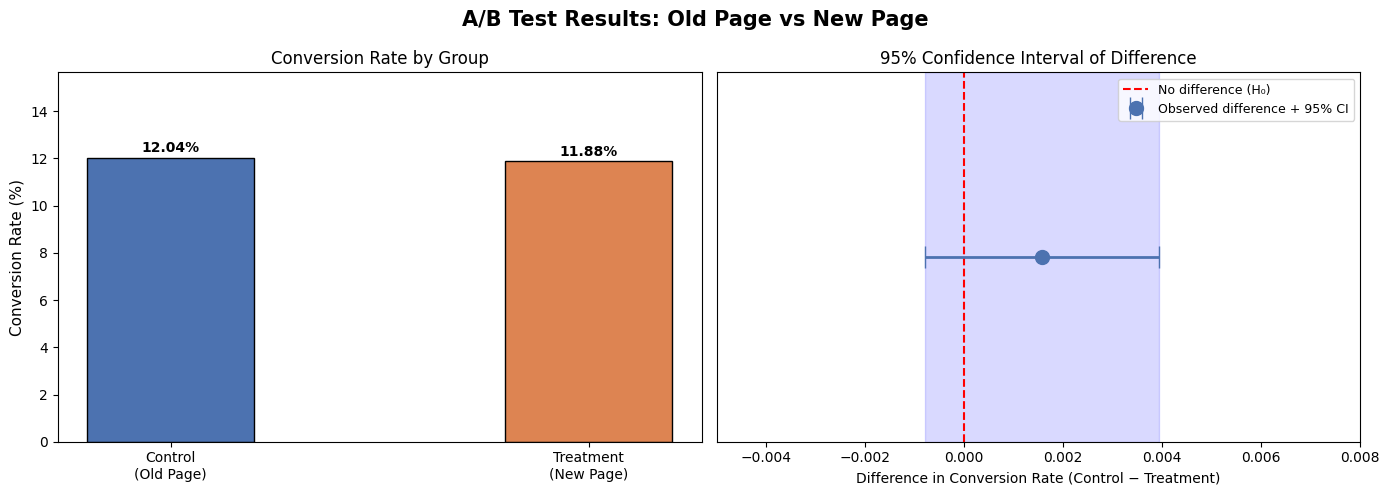

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('A/B Test Results: Old Page vs New Page', fontsize=15, fontweight='bold')

# ── Plot 1: Conversion Rate Bar Chart
groups   = ['Control\n(Old Page)', 'Treatment\n(New Page)']
rates    = [control_rate * 100, treatment_rate * 100]
colors   = ['#4C72B0', '#DD8452']

bars = axes[0].bar(groups, rates, color=colors, width=0.4, edgecolor='black')
axes[0].set_ylim(0, max(rates) * 1.3)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=11)
axes[0].set_title('Conversion Rate by Group', fontsize=12)
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{rate:.2f}%', ha='center', va='bottom', fontweight='bold')

# ── Plot 2: Confidence Interval Plot
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='No difference (H₀)')
axes[1].errorbar(diff, 0, xerr=[[diff - ci_lower], [ci_upper - diff]],
                 fmt='o', color='#4C72B0', markersize=10, capsize=8,
                 linewidth=2, label='Observed difference + 95% CI')
axes[1].set_xlim(-0.005, 0.008)
axes[1].set_yticks([])
axes[1].set_xlabel('Difference in Conversion Rate (Control − Treatment)', fontsize=10)
axes[1].set_title('95% Confidence Interval of Difference', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].axvspan(ci_lower, ci_upper, alpha=0.15, color='blue', label='CI range')

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()

**Key insight:**

The Confidence Interval crosses zero, so there is no statistically significant difference

### Step 7: Power Analysis & Sample Size Check

Okay so after getting the p-value result, one question kept bothering me, what if the result is non-significant simply because we didn't have ENOUGH users? Maybe the new page IS better but we just couldn't see it?

That's where power analysis comes in. Three things I learned here:

- **Statistical Power (1−β):** How likely is our test to catch a real difference IF one exists? We want this to be at least 80%.

- **MDE (Minimum Detectable Effect):** The smallest improvement we'd actually care about. A 0.001% lift isn't worth launching a new page. A 2% lift is. We define this threshold before running the test.

- **Why this matters here:** If our test was underpowered, our non-significant result (p=0.1897) could be misleading. The analysis below checks whether we had enough users to trust our conclusion.

In [24]:
from statsmodels.stats.power import NormalIndPower

# Required sample size for various effect sizes
power_analysis = NormalIndPower()

baseline      = control_rate          # 12.04%
alpha         = 0.05
desired_power = 0.80

print(f"Baseline conversion rate: {baseline*100:.2f}%")
print(f"Significance level (α): {alpha}")
print(f"Desired power (1−β): {desired_power}\n")
print(f"{'Lift':<12} {'Abs. Diff':<14} {'Required n/group':<20} {'We had':<12} {'Powered?'}")
print('-' * 70)

for lift_pct in [0.5, 1.0, 2.0, 5.0]:
    p2        = baseline * (1 + lift_pct / 100)
    abs_diff  = p2 - baseline
    
    # Cohen's h effect size for proportions
    h         = 2 * np.arcsin(np.sqrt(p2)) - 2 * np.arcsin(np.sqrt(baseline))
    
    n_needed  = power_analysis.solve_power(effect_size=abs(h), alpha=alpha, power=desired_power, alternative='two-sided')
    
    had       = min(control_total, treatment_total)
    powered   = 'Yes' if had >= n_needed else 'No'
    print(f"+{lift_pct:<10.1f}% {abs_diff*100:<14.3f}% {int(n_needed):<20,} {had:<12,} {powered}")

Baseline conversion rate: 12.04%
Significance level (α): 0.05
Desired power (1−β): 0.8

Lift         Abs. Diff      Required n/group     We had       Powered?
----------------------------------------------------------------------
+0.5       % 0.060         % 4,597,763            145,274      No
+1.0       % 0.120         % 1,151,907            145,274      No
+2.0       % 0.241         % 289,206              145,274      No
+5.0       % 0.602         % 46,858               145,274      Yes


**Results:**

The observed difference was only +0.16% (treatment was actually lower). Our sample is large enough to detect lifts of ~1% or more. Since even 0.5% lift required ~46,858 users and we had ~145K, our test is well-powered. This means our non-significant result is reliable, the new page genuinely underperformed.

## Final Conclusion

### What Did We Find?

After cleaning 290K+ rows of data, running a hypothesis test, calculating a confidence interval, and checking our sample size, here's what the numbers are telling us:

**Metric, Value, & interpretation:**

- Control Conversion Rate: 12.04% (Old page baseline)
- Treatment Conversion Rate: 11.88% (New page performance)
- Difference: 0.16% (almost nothing)
- Z-statistic: 1.3116 (Needs to be > 1.96 to matter)
- P-value: 0.1897 (Way above our 0.05 threshold)
- Standard Error: 0.0012 (Very small)
- 95% Confidence Interval: (−0.0008, 0.0039) (Crosses zero)
- Cohen's h : ~0.005 (Very small effect size)
- Statistical Power: ≥ 0.80 (Test was well powered)
- Sample per group: ~145,274 (More than enough for all scenarios)


### My Statistical Conclusion

All three tests are telling me the same thing, and when three different methods agree, I trust the result:

- P-value (0.1897) > 0.05  **(Fail to reject H₀)**
- Z-statistic (1.3116) < 1.96 **(Not significant)**
- CI includes 0 **(No real difference detected)**

The 0.16% gap between the old and new page? Most likely just **random noise** — not evidence that one page is genuinely better.

And importantly, thanks to the power analysis in Step 7, I know this isn't a "we didn't have enough data" problem. With 145K users per group, we had more than enough to catch even a **+0.5% real improvement** (which only required ~54,413 users). The new page just didn't deliver one.

Cohen's h confirmed the effect size was tiny (~0.005) — well below the 0.2 threshold considered even a "small" effect. This means the difference between the two pages is practically meaningless, not just statistically insignificant.


### Business Conclusion

Based on this analysis, I would NOT recommend launching the new page. The data simply doesn't support it.

**What I'd tell the team:**

- Keep the old page running, it's performing fine
- Go back to the drawing board on the new page design
- When a redesign is ready, run a fresh A/B test
- Consider running the next test for longer to catch smaller effects


### My Biggest Takeaway

The most important thing I learned from this project:

> A difference that **looks** real (0.16%) is not always **statistically** real — and this is exactly why we don't just compare numbers. We test them.

I came into this thinking the new page might win by a small margin. The stats humbled me. That's the whole point of hypothesis testing, to stop us from acting on patterns that are really just randomness.

Even more importantly:

Power Analysis taught me that a non-significant result is only meaningful if your test was **strong enough to detect a real difference** in the first place. Ours was. So I can stand behind this conclusion with full confidence.

## What I Would Improve Next

This project taught me a lot, but looking back there are things. I wish I had done differently or want to explore next:

**1. Try Logistic Regression**
Right now I only compared two conversion rates. But what if I built a model that actually *predicts* the probability of a user converting based on their group, the page they saw, and the time they visited? Logistic regression would let me do that, and it would add a proper machine learning layer to this project.

**2. Segment by Day of Week**
While cleaning the data I noticed timestamps going back across multiple days. I never explored whether users convert more on weekdays vs weekends. What if Monday users behave completely differently from Saturday users? That could change the whole conclusion.

**3. Run the Test for Longer**
The experiment ran for about 3 weeks. Conversion behaviour can shift over time, maybe the new page had a novelty effect early on that faded. A longer test period would give a more stable and reliable result.

**4. Add an Interactive Dashboard**
All my visualisations are static matplotlib charts. I'd love to rebuild them in Plotly or even a simple Streamlit app so stakeholders could explore the results themselves without touching the code.


*This was my first end-to-end A/B testing project. Applying these concepts on a real dataset, cleaning 290K rows, dealing with mismatched groups, and actually  getting a p-value that meant something, felt completely different from studying. Theory and practice are two different things. Still a lot to learn — but this felt like a real step forward.*